# NIH ChestX-ray14 — Multi-Label Chest Pathology Classification
#
Executable pipeline: EDA, patient-disjoint split, ResNet-18 training,
bootstrap CIs, subgroup breakdown, Grad-CAM pointing-game localization,
and two ablations (split leakage, pos_weight on/off).
#
Narrative, method justification, and interpretation live in the project
README — this notebook is the evidence trail, not the write-up.
#
Requirements: see requirements.txt

In [1]:
import os
import subprocess
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import seaborn as sns
from PIL import Image

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
import torchvision.models as models
import torchvision.transforms as transforms
from sklearn.metrics import roc_auc_score

## 1. Config

In [2]:
MINI_RUN = False   # True = quick pipeline test (small subsample) | False = full run

SEED = 42
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

if os.path.exists("/kaggle/input"):
    BASE = Path("/kaggle/input/datasets/khanfashee/nih-chest-x-ray-14-224x224-resized")
else:
    BASE = Path(os.environ.get("NIH_DATA_DIR", "./data/nih-chest-xray14"))

# Pre-resized 224x224 by a third-party Kaggle upload, not the official NIH
# release (README > Limitations).
IMG_DIR    = BASE / "images-224" / "images-224"
CSV_PATH   = BASE / "Data_Entry_2017.csv"
TRAIN_LIST = BASE / "train_val_list_NIH.txt"
TEST_LIST  = BASE / "test_list_NIH.txt"

IMG_SIZE = 224
RESIZE_NEEDED = False

BATCH_SIZE     = 32
MAX_EPOCHS     = 20
EARLY_PATIENCE = 4
LR             = 1e-4

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

OUT_DIR = Path("./outputs")
FIG_DIR = Path("./figures")
CKPT_DIR = Path("/kaggle/working") if os.path.exists("/kaggle/working") else Path(".")
OUT_DIR.mkdir(exist_ok=True)
FIG_DIR.mkdir(exist_ok=True)

def ckpt_path(name: str) -> Path:
    return CKPT_DIR / f"{name}.pth"

MAIN_CKPT = ckpt_path("main_best")
SKIP_MAIN_TRAINING_IF_CHECKPOINT_EXISTS = True  # loads main_best.pth instead of retraining, if present

LABELS = [
    "Atelectasis", "Consolidation", "Infiltration", "Pneumothorax",
    "Edema", "Emphysema", "Fibrosis", "Effusion", "Pneumonia",
    "Pleural_Thickening", "Cardiomegaly", "Nodule", "Mass", "Hernia"
]

print(f"Device: {DEVICE}")
print(f"Mode:   {'MINI' if MINI_RUN else 'FULL'}")
print(f"CSV exists: {CSV_PATH.exists()} | Train list: {TRAIN_LIST.exists()} | Test list: {TEST_LIST.exists()}")

Device: cuda
Mode:   FULL
CSV exists: True | Train list: True | Test list: True


## 2. Load Data

In [3]:
df = pd.read_csv(CSV_PATH)
print(f"Shape: {df.shape}")

Shape: (112120, 12)


## 3. Parse Multi-Label Column

In [4]:
assert not any(a in b for a in LABELS for b in LABELS if a != b), \
    "A label name is a substring of another — substring matching below would misfire."

for label in LABELS:
    df[label] = df["Finding Labels"].apply(lambda x: 1 if label in x else 0)

print(f"Total images: {len(df):,} | No Finding: {(df['Finding Labels'] == 'No Finding').sum():,} "
      f"| >=1 condition: {(df['Finding Labels'] != 'No Finding').sum():,}")

Total images: 112,120 | No Finding: 60,412 | >=1 condition: 51,708


## 4. Class Distribution

Positive counts and rates per class:
  Infiltration           19,870  (17.7%)
  Effusion               13,307  (11.9%)
  Atelectasis            11,535  (10.3%)
  Nodule                  6,323  (5.6%)
  Mass                    5,746  (5.1%)
  Pneumothorax            5,298  (4.7%)
  Consolidation           4,667  (4.2%)
  Pleural_Thickening      3,385  (3.0%)
  Cardiomegaly            2,772  (2.5%)
  Emphysema               2,516  (2.2%)
  Edema                   2,303  (2.0%)
  Fibrosis                1,686  (1.5%)
  Pneumonia               1,353  (1.2%)
  Hernia                    227  (0.2%)


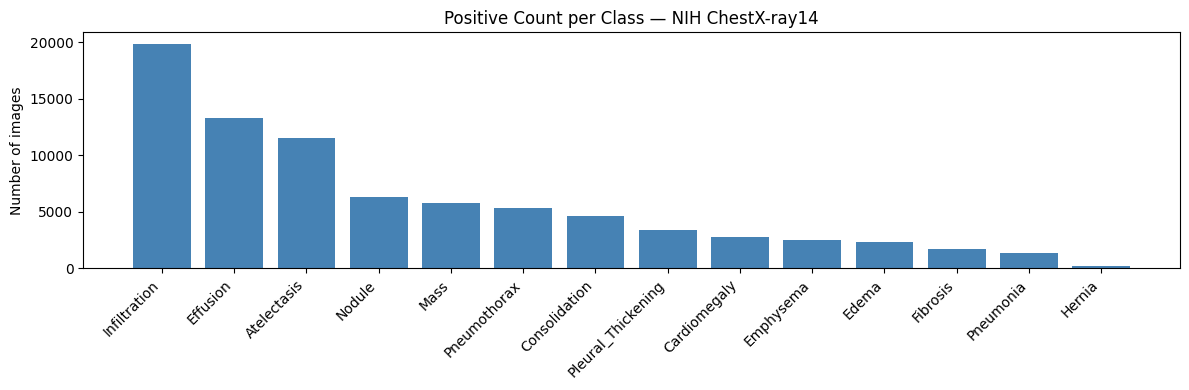

In [5]:
label_counts = df[LABELS].sum().sort_values(ascending=False)
label_pct = (label_counts / len(df) * 100).round(2)
print("Positive counts and rates per class:")
for label in label_counts.index:
    print(f"  {label:<22} {label_counts[label]:6,}  ({label_pct[label]:.1f}%)")

plt.figure(figsize=(12, 4))
plt.bar(label_counts.index, label_counts.values, color="steelblue")
plt.title("Positive Count per Class — NIH ChestX-ray14")
plt.ylabel("Number of images")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.savefig(FIG_DIR / "class_distribution.png", dpi=120)
plt.show()

## 5. Label Co-occurrence

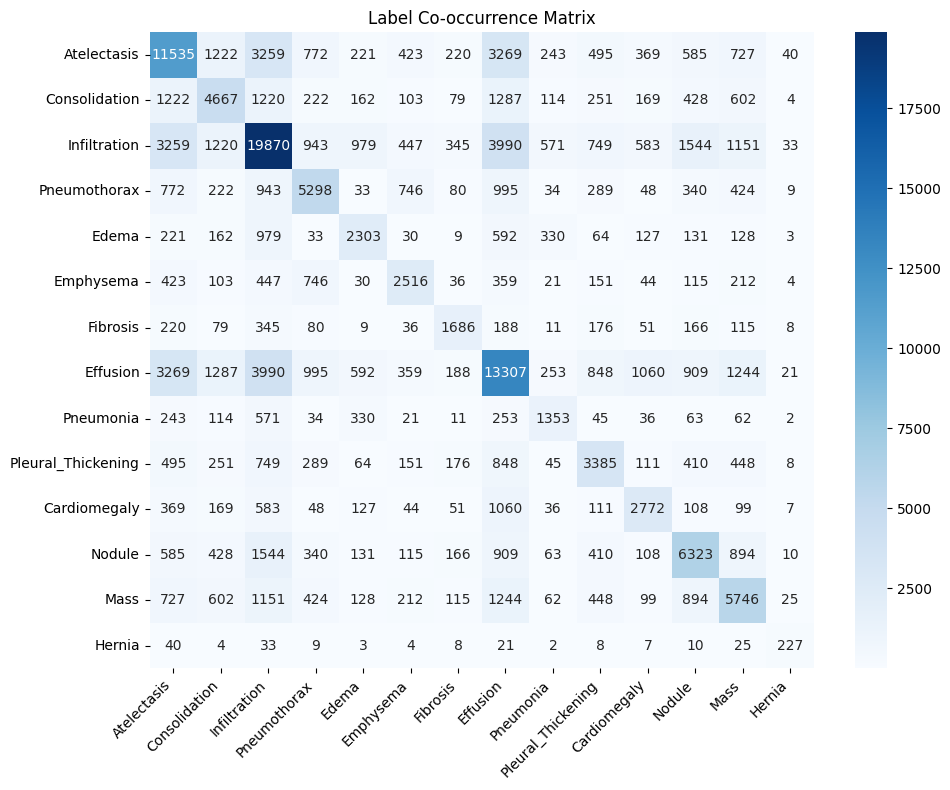

In [6]:
co_matrix = df[LABELS].T.dot(df[LABELS])
plt.figure(figsize=(10, 8))
sns.heatmap(co_matrix, annot=True, fmt="d", cmap="Blues", xticklabels=LABELS, yticklabels=LABELS)
plt.title("Label Co-occurrence Matrix")
plt.xticks(rotation=45, ha="right")
plt.yticks(rotation=0)
plt.tight_layout()
plt.savefig(FIG_DIR / "co_occurrence.png", dpi=120)
plt.show()

## 6. Patient-Disjoint Train / Val / Test Split

In [7]:
train_val_files = set(open(TRAIN_LIST).read().splitlines())
test_files      = set(open(TEST_LIST).read().splitlines())

df_trainval = df[df["Image Index"].isin(train_val_files)].copy()
df_test     = df[df["Image Index"].isin(test_files)].copy()

trainval_patients = df_trainval["Patient ID"].unique()
np.random.shuffle(trainval_patients)
n_val = int(len(trainval_patients) * 0.10)
val_patients = set(trainval_patients[:n_val])

df_train = df_trainval[~df_trainval["Patient ID"].isin(val_patients)]
df_val   = df_trainval[df_trainval["Patient ID"].isin(val_patients)]

assert len(set(df_train["Patient ID"]) & set(df_val["Patient ID"]))  == 0
assert len(set(df_train["Patient ID"]) & set(df_test["Patient ID"])) == 0
assert len(set(df_val["Patient ID"])   & set(df_test["Patient ID"])) == 0
print(f"Train: {len(df_train):,} ({df_train['Patient ID'].nunique():,} pt) | "
      f"Val: {len(df_val):,} ({df_val['Patient ID'].nunique():,} pt) | "
      f"Test: {len(df_test):,} ({df_test['Patient ID'].nunique():,} pt)")
print("Patient overlap check: PASSED")

if MINI_RUN:
    df_train = df_train.sample(n=min(1000, len(df_train)), random_state=SEED)
    df_val   = df_val.sample(n=min(200,  len(df_val)),   random_state=SEED)
    df_test  = df_test.sample(n=min(200,  len(df_test)),  random_state=SEED)
    print(f"MINI — Train: {len(df_train)} | Val: {len(df_val)} | Test: {len(df_test)}")

Train: 77,994 (25,208 pt) | Val: 8,530 (2,800 pt) | Test: 25,596 (2,797 pt)
Patient overlap check: PASSED


## 7. Dataset, Transforms, Loaders

In [8]:
class ChestXrayDataset(Dataset):
    def __init__(self, df, img_dir, transform=None):
        self.df = df.reset_index(drop=True)
        self.img_dir = img_dir
        self.transform = transform

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        img = Image.open(self.img_dir / row["Image Index"]).convert("RGB")
        label = torch.tensor(row[LABELS].values.astype(np.float32))
        if self.transform:
            img = self.transform(img)
        return img, label


imagenet_mean = [0.485, 0.456, 0.406]
imagenet_std  = [0.229, 0.224, 0.225]
_resize = [transforms.Resize(IMG_SIZE)] if RESIZE_NEEDED else []

train_transform = transforms.Compose(_resize + [
    transforms.RandomHorizontalFlip(p=0.5),   # justified in README > Method
    transforms.ToTensor(),
    transforms.Normalize(mean=imagenet_mean, std=imagenet_std),
])
val_test_transform = transforms.Compose(_resize + [
    transforms.ToTensor(),
    transforms.Normalize(mean=imagenet_mean, std=imagenet_std),
])

def make_loaders(train_df, val_df, test_df, batch_size=BATCH_SIZE):
    train_ds = ChestXrayDataset(train_df, IMG_DIR, transform=train_transform)
    val_ds   = ChestXrayDataset(val_df,   IMG_DIR, transform=val_test_transform)
    test_ds  = ChestXrayDataset(test_df,  IMG_DIR, transform=val_test_transform)
    return (
        DataLoader(train_ds, batch_size=batch_size, shuffle=True,  num_workers=2, pin_memory=True),
        DataLoader(val_ds,   batch_size=batch_size, shuffle=False, num_workers=2, pin_memory=True),
        DataLoader(test_ds,  batch_size=batch_size, shuffle=False, num_workers=2, pin_memory=True),
        train_ds, val_ds, test_ds,
    )

train_loader, val_loader, test_loader, train_ds, val_ds, test_ds = make_loaders(df_train, df_val, df_test)

## 8. pos_weight, Model, Shared Helper Functions

In [9]:
def compute_pos_weight(train_df):
    pos_counts = train_df[LABELS].sum().values.astype(np.float32)
    neg_counts = len(train_df) - pos_counts
    return torch.tensor(neg_counts / np.clip(pos_counts, 1, None), dtype=torch.float32).to(DEVICE)

pos_weight = compute_pos_weight(df_train)
print("Per-class pos_weight (main train split):")
for i, label in enumerate(LABELS):
    print(f"  {label:<22} weight={pos_weight[i].item():.1f}")


def build_model():
    m = models.resnet18(weights="IMAGENET1K_V1")
    m.fc = nn.Linear(512, 14)
    return m.to(DEVICE)


def evaluate_model(model, loader):
    model.eval()
    probs, targets = [], []
    with torch.no_grad():
        for imgs, labels in loader:
            p = torch.sigmoid(model(imgs.to(DEVICE))).cpu().numpy()
            probs.extend(p)
            targets.extend(labels.numpy())
    return np.array(probs), np.array(targets)


def mean_auc(targets, probs, label_names=LABELS):
    aucs = []
    for i in range(len(label_names)):
        if targets[:, i].sum() > 0:
            try:
                aucs.append(roc_auc_score(targets[:, i], probs[:, i]))
            except ValueError:
                pass
    return float(np.mean(aucs)) if aucs else float("nan")


def per_class_auc(targets, probs, label_names=LABELS):
    out = {}
    for i, lab in enumerate(label_names):
        if targets[:, i].sum() > 0:
            try:
                out[lab] = roc_auc_score(targets[:, i], probs[:, i])
            except ValueError:
                out[lab] = np.nan
        else:
            out[lab] = np.nan
    return out


def sensitivity_at_threshold(y_true, y_prob, threshold=0.5):
    """Fraction of true positives flagged at this threshold — distinct from
    AUC, which is threshold-independent (rank-based)."""
    pos_mask = y_true == 1
    if pos_mask.sum() == 0:
        return float("nan")
    return float((y_prob[pos_mask] >= threshold).mean())


def train_model(model, train_loader, val_loader, epochs, pos_weight_tensor,
                 lr=LR, patience=EARLY_PATIENCE, ckpt=MAIN_CKPT, tag="model"):
    criterion = (nn.BCEWithLogitsLoss(pos_weight=pos_weight_tensor)
                 if pos_weight_tensor is not None else nn.BCEWithLogitsLoss())
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode="max", patience=2, factor=0.5)

    best_auc, patience_count = 0.0, 0
    history = {"train_loss": [], "val_auc": []}

    for epoch in range(1, epochs + 1):
        model.train()
        running_loss = 0.0
        for imgs, labels in train_loader:
            imgs, labels = imgs.to(DEVICE), labels.to(DEVICE)
            optimizer.zero_grad()
            loss = criterion(model(imgs), labels)
            loss.backward()
            optimizer.step()
            running_loss += loss.item() * len(imgs)
        train_loss = running_loss / len(train_loader.dataset)

        val_probs, val_targets = evaluate_model(model, val_loader)
        val_auc = mean_auc(val_targets, val_probs)
        scheduler.step(val_auc)

        history["train_loss"].append(train_loss)
        history["val_auc"].append(val_auc)
        print(f"[{tag}] Epoch {epoch:02d}/{epochs} | Train Loss {train_loss:.4f} | "
              f"Val AUC {val_auc:.4f} | LR {optimizer.param_groups[0]['lr']:.2e}")

        if val_auc > best_auc:
            best_auc, patience_count = val_auc, 0
            torch.save(model.state_dict(), ckpt)
        else:
            patience_count += 1
            if patience_count >= patience:
                print(f"[{tag}] Early stopping at epoch {epoch}.")
                break

    model.load_state_dict(torch.load(ckpt))
    return model, history, best_auc

Per-class pos_weight (main train split):
  Atelectasis            weight=9.5
  Consolidation          weight=29.2
  Infiltration           weight=5.2
  Pneumothorax           weight=31.6
  Edema                  weight=61.2
  Emphysema              weight=58.2
  Fibrosis               weight=69.2
  Effusion               weight=8.9
  Pneumonia              weight=98.6
  Pleural_Thickening     weight=38.1
  Cardiomegaly           weight=49.4
  Nodule                 weight=17.4
  Mass                   weight=20.4
  Hernia                 weight=638.3


## 9. Main Training Run

Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 184MB/s]


Training main model...
[main] Epoch 01/20 | Train Loss 1.1247 | Val AUC 0.7812 | LR 1.00e-04
[main] Epoch 02/20 | Train Loss 1.0352 | Val AUC 0.7625 | LR 1.00e-04
[main] Epoch 03/20 | Train Loss 0.9851 | Val AUC 0.7999 | LR 1.00e-04
[main] Epoch 04/20 | Train Loss 0.9459 | Val AUC 0.8071 | LR 1.00e-04
[main] Epoch 05/20 | Train Loss 0.9102 | Val AUC 0.8101 | LR 1.00e-04
[main] Epoch 06/20 | Train Loss 0.8607 | Val AUC 0.8179 | LR 1.00e-04
[main] Epoch 07/20 | Train Loss 0.8135 | Val AUC 0.8109 | LR 1.00e-04
[main] Epoch 08/20 | Train Loss 0.7706 | Val AUC 0.8057 | LR 1.00e-04
[main] Epoch 09/20 | Train Loss 0.7183 | Val AUC 0.8043 | LR 5.00e-05
[main] Epoch 10/20 | Train Loss 0.6155 | Val AUC 0.8087 | LR 5.00e-05
[main] Early stopping at epoch 10.


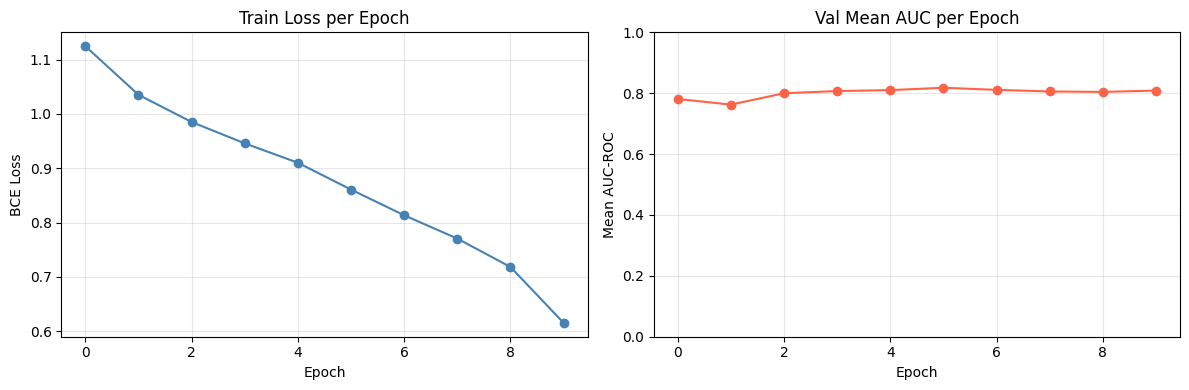

In [10]:
model = build_model()

if SKIP_MAIN_TRAINING_IF_CHECKPOINT_EXISTS and MAIN_CKPT.exists():
    print(f"Found existing checkpoint at {MAIN_CKPT} — loading instead of retraining.")
    model.load_state_dict(torch.load(MAIN_CKPT))
    history = None
else:
    print("Training main model...")
    model, history, best_val_auc = train_model(
        model, train_loader, val_loader, MAX_EPOCHS, pos_weight,
        ckpt=MAIN_CKPT, tag="main"
    )

if history is not None:
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))
    ax1.plot(history["train_loss"], marker="o", color="steelblue")
    ax1.set_title("Train Loss per Epoch"); ax1.set_xlabel("Epoch"); ax1.set_ylabel("BCE Loss")
    ax1.grid(True, alpha=0.3)
    ax2.plot(history["val_auc"], marker="o", color="tomato")
    ax2.set_title("Val Mean AUC per Epoch"); ax2.set_xlabel("Epoch"); ax2.set_ylabel("Mean AUC-ROC")
    ax2.set_ylim(0, 1); ax2.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.savefig(FIG_DIR / "training_curves.png", dpi=120)
    plt.show()

## 10. Test Evaluation + Bootstrap Confidence Intervals

In [11]:
test_probs, test_targets = evaluate_model(model, test_loader)
class_aucs = per_class_auc(test_targets, test_probs)

print(f"{'Class':<22} {'AUC':>6}")
print("-" * 30)
for label, auc in sorted(class_aucs.items(), key=lambda x: (-x[1] if not np.isnan(x[1]) else 999)):
    print(f"{label:<22} {auc:.4f}" if not np.isnan(auc) else f"{label:<22}   N/A")
print("-" * 30)
print(f"{'Mean AUC':<22} {np.nanmean(list(class_aucs.values())):.4f}")


def bootstrap_auc_ci(y_true, y_score, n_boot=1000, ci=0.95, seed=SEED):
    rng = np.random.RandomState(seed)
    n = len(y_true)
    boot_aucs = []
    for _ in range(n_boot):
        idx = rng.randint(0, n, n)
        y_t, y_s = y_true[idx], y_score[idx]
        if y_t.sum() == 0 or y_t.sum() == n:
            continue
        boot_aucs.append(roc_auc_score(y_t, y_s))
    boot_aucs = np.array(boot_aucs)
    lo = np.percentile(boot_aucs, (1 - ci) / 2 * 100)
    hi = np.percentile(boot_aucs, (1 + ci) / 2 * 100)
    return lo, hi

auc_ci_rows = []
for i, label in enumerate(LABELS):
    y_true, y_score = test_targets[:, i], test_probs[:, i]
    n_pos = int(y_true.sum())
    if n_pos == 0:
        continue
    point_auc = roc_auc_score(y_true, y_score)
    lo, hi = bootstrap_auc_ci(y_true, y_score)
    auc_ci_rows.append({"Class": label, "AUC": round(point_auc, 4),
                         "CI_low": round(lo, 4), "CI_high": round(hi, 4),
                         "Test_positives": n_pos})

auc_ci_df = pd.DataFrame(auc_ci_rows).sort_values("AUC", ascending=False)
print(auc_ci_df.to_string(index=False))
auc_ci_df.to_csv(OUT_DIR / "test_auc_bootstrap_ci.csv", index=False)

Class                     AUC
------------------------------
Hernia                 0.9189
Emphysema              0.8822
Cardiomegaly           0.8666
Pneumothorax           0.8339
Edema                  0.8334
Effusion               0.8107
Fibrosis               0.8039
Mass                   0.7782
Pleural_Thickening     0.7568
Atelectasis            0.7499
Consolidation          0.7242
Nodule                 0.7151
Infiltration           0.6955
Pneumonia              0.6806
------------------------------
Mean AUC               0.7893
             Class    AUC  CI_low  CI_high  Test_positives
            Hernia 0.9189  0.8795   0.9539              86
         Emphysema 0.8822  0.8721   0.8925            1093
      Cardiomegaly 0.8666  0.8568   0.8769            1065
      Pneumothorax 0.8339  0.8259   0.8409            2661
             Edema 0.8334  0.8220   0.8443             925
          Effusion 0.8107  0.8045   0.8174            4648
          Fibrosis 0.8039  0.7829   0.8250   

## 11. Subgroup Breakdown — Gender, Age, View Position

In [12]:
def parse_patient_age(raw_series):
    digits = raw_series.astype(str).str.extract(r"(\d+)", expand=False)
    parsed = pd.to_numeric(digits, errors="coerce")
    n_failed = int(parsed.isna().sum())
    if n_failed > 0:
        print(f"WARNING: {n_failed} / {len(parsed)} Patient Age values could not be parsed.")
    return parsed

test_meta = test_ds.df.copy().reset_index(drop=True)
test_meta["Patient Age"] = parse_patient_age(test_meta["Patient Age"])
test_meta.loc[test_meta["Patient Age"] > 100, "Patient Age"] = np.nan
age_bins, age_labels = [0, 40, 60, 120], ["<40", "40-60", "60+"]
test_meta["Age Band"] = pd.cut(test_meta["Patient Age"], bins=age_bins, labels=age_labels, right=False)

def stratified_auc(mask, class_idx):
    y_t, y_s = test_targets[mask, class_idx], test_probs[mask, class_idx]
    n_pos = int(y_t.sum())
    if n_pos == 0 or n_pos == len(y_t):
        return np.nan, n_pos
    return roc_auc_score(y_t, y_s), n_pos

def stratified_table(column, values):
    rows = []
    for i, label in enumerate(LABELS):
        for v in values:
            mask = (test_meta[column] == v).values
            auc, n_pos = stratified_auc(mask, i)
            rows.append({"Class": label, column: v, "AUC": auc, "n_pos": n_pos, "n_total": int(mask.sum())})
    return pd.DataFrame(rows)

gender_df = stratified_table("Patient Gender", ["M", "F"])
gender_pivot = gender_df.pivot(index="Class", columns="Patient Gender", values="AUC")
gender_pivot["Gap (M-F)"] = gender_pivot["M"] - gender_pivot["F"]
gender_df.to_csv(OUT_DIR / "subgroup_auc_gender.csv", index=False)
print("--- AUC by Gender ---")
print(gender_pivot.sort_values("Gap (M-F)", key=abs, ascending=False).round(4))
# no per-subgroup CI computed — treat as descriptive, not confirmed (README > Results)

age_df = stratified_table("Age Band", age_labels)
age_pivot = age_df.pivot(index="Class", columns="Age Band", values="AUC")
age_df.to_csv(OUT_DIR / "subgroup_auc_age.csv", index=False)
print("\n--- AUC by Age Band ---")
print(age_pivot.round(4))
# check n_pos in age_df before trusting any single cell (Hernia <40 is a known low-n artifact)

view_df = stratified_table("View Position", ["AP", "PA"])
view_pivot = view_df.pivot(index="Class", columns="View Position", values="AUC")
view_pivot["Gap (AP-PA)"] = view_pivot["AP"] - view_pivot["PA"]
view_df.to_csv(OUT_DIR / "view_position_auc.csv", index=False)
print("\n--- AUC by View Position (acquisition-bias hypothesis check) ---")
hypothesis_classes = ["Pneumothorax", "Effusion", "Atelectasis"]
print(view_pivot.loc[hypothesis_classes].round(4))

--- AUC by Gender ---
Patient Gender           F       M  Gap (M-F)
Class                                        
Hernia              0.9568  0.8768    -0.0800
Fibrosis            0.7589  0.8388     0.0799
Nodule              0.7379  0.6994    -0.0385
Effusion            0.7943  0.8221     0.0278
Pleural_Thickening  0.7667  0.7494    -0.0173
Atelectasis         0.7425  0.7552     0.0127
Mass                0.7722  0.7818     0.0096
Cardiomegaly        0.8623  0.8700     0.0077
Pneumothorax        0.8375  0.8302    -0.0072
Consolidation       0.7259  0.7225    -0.0033
Pneumonia           0.6793  0.6813     0.0020
Infiltration        0.6942  0.6961     0.0019
Edema               0.8340  0.8330    -0.0010
Emphysema           0.8812  0.8814     0.0002

--- AUC by Age Band ---
Age Band             40-60     60+     <40
Class                                     
Atelectasis         0.7421  0.7430  0.7525
Cardiomegaly        0.8813  0.8363  0.8641
Consolidation       0.7108  0.7492  0.7227
Ed

## 12. Quantitative Grad-CAM — Pointing Game

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.8/7.8 MB 56.6 MB/s eta 0:00:00
--- Grad-CAM localization: pointing-game accuracy by class ---
                n  pointing_game_accuracy
Class                                    
Cardiomegaly  146                  0.9589
Infiltration  123                  0.4553
Pneumonia     120                  0.4417
Effusion      153                  0.3333
Mass           85                  0.3059
Atelectasis   180                  0.2500
Pneumothorax   98                  0.0816
Nodule         79                  0.0380


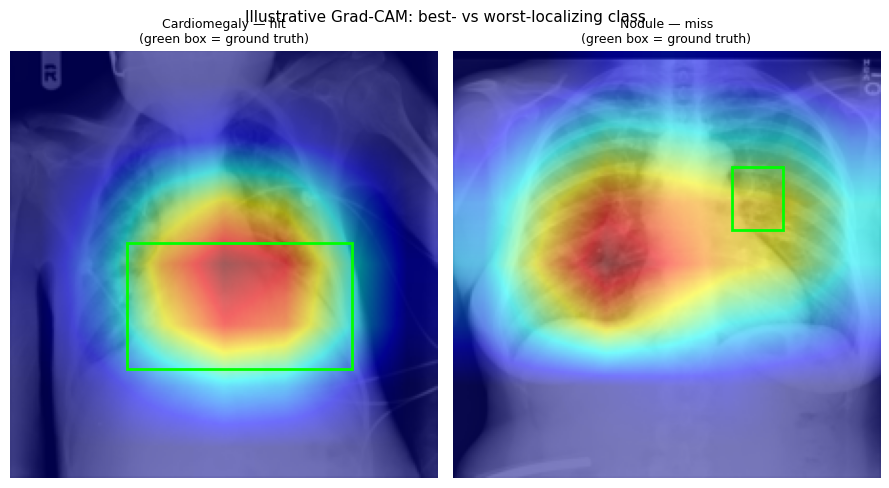

In [13]:
subprocess.run(["pip", "install", "grad-cam", "-q"])
from pytorch_grad_cam import GradCAM
from pytorch_grad_cam.utils.image import show_cam_on_image
from pytorch_grad_cam.utils.model_targets import ClassifierOutputTarget

cam_model = build_model()
cam_model.load_state_dict(torch.load(MAIN_CKPT))
cam_model.eval()
cam = GradCAM(model=cam_model, target_layers=[cam_model.layer4[-1]])

BBOX_CANDIDATES = [
    BASE / "BBox_List_2017_Official_NIH.csv",
    BASE / "BBox_List_2017.csv",
    Path("/kaggle/input/data/BBox_List_2017.csv"),
]
bbox_path = next((p for p in BBOX_CANDIDATES if p.exists()), None)
if bbox_path is None:
    raise FileNotFoundError("No bounding-box CSV found among BBOX_CANDIDATES.")

bbox_df = pd.read_csv(bbox_path)
bbox_df.columns = ["Image_Index", "Finding_Label", "x", "y", "w", "h"] + list(bbox_df.columns[6:])
bbox_df["Finding_Label"] = bbox_df["Finding_Label"].replace({"Infiltrate": "Infiltration"})
bbox_test = bbox_df[bbox_df["Image_Index"].isin(set(df_test["Image Index"]))].copy()

ORIG_SIZE = 1024
scale = IMG_SIZE / ORIG_SIZE
bbox_test["x_s"] = bbox_test["x"] * scale
bbox_test["y_s"] = bbox_test["y"] * scale
bbox_test["w_s"] = bbox_test["w"] * scale
bbox_test["h_s"] = bbox_test["h"] * scale

def pointing_game_hit(heatmap, gt_box):
    y_peak, x_peak = np.unravel_index(np.argmax(heatmap), heatmap.shape)
    x, y, w, h = gt_box
    return (x <= x_peak <= x + w) and (y <= y_peak <= y + h)

LABEL_TO_IDX = {l: i for i, l in enumerate(LABELS)}
localization_rows = []
for _, row in bbox_test.iterrows():
    label = row["Finding_Label"]
    if label not in LABEL_TO_IDX:
        continue
    img_path = IMG_DIR / row["Image_Index"]
    if not img_path.exists():
        continue
    img_pil = Image.open(img_path).convert("RGB")
    img_tensor = val_test_transform(img_pil).unsqueeze(0).to(DEVICE)
    heatmap = cam(input_tensor=img_tensor, targets=[ClassifierOutputTarget(LABEL_TO_IDX[label])])[0]
    gt_box = (row["x_s"], row["y_s"], row["w_s"], row["h_s"])
    hit = pointing_game_hit(heatmap, gt_box)
    localization_rows.append({"Image_Index": row["Image_Index"], "Class": label, "hit": hit,
                               "x": row["x_s"], "y": row["y_s"], "w": row["w_s"], "h": row["h_s"]})

loc_df = pd.DataFrame(localization_rows)
loc_summary = loc_df.groupby("Class")["hit"].agg(n="count", pointing_game_accuracy="mean")
loc_summary = loc_summary.sort_values("pointing_game_accuracy", ascending=False).round(4)
print("--- Grad-CAM localization: pointing-game accuracy by class ---")
print(loc_summary.to_string())
loc_df.to_csv(OUT_DIR / "gradcam_pointing_game_raw.csv", index=False)
loc_summary.to_csv(OUT_DIR / "gradcam_pointing_game_summary.csv")
# "chance" scales with box size relative to image area — not corrected for here (README > Results)

# 2 illustrative examples tied to the table above (not a standalone qualitative check)
best_class = loc_summary.index[0]
worst_class = loc_summary.index[-1]

def get_example(cls, want_hit):
    subset = loc_df[(loc_df["Class"] == cls) & (loc_df["hit"] == want_hit)]
    if len(subset) == 0:
        subset = loc_df[loc_df["Class"] == cls]
    return subset.iloc[0]

best_example = get_example(best_class, want_hit=True)
worst_example = get_example(worst_class, want_hit=False)

fig, axes = plt.subplots(1, 2, figsize=(9, 5))
for ax, example, cls in zip(axes, [best_example, worst_example], [best_class, worst_class]):
    img_pil = Image.open(IMG_DIR / example["Image_Index"]).convert("RGB")
    img_np = np.array(img_pil).astype(np.float32) / 255.0
    img_tensor = val_test_transform(img_pil).unsqueeze(0).to(DEVICE)
    heatmap = cam(input_tensor=img_tensor, targets=[ClassifierOutputTarget(LABEL_TO_IDX[cls])])[0]
    overlay = show_cam_on_image(img_np, heatmap, use_rgb=True)
    ax.imshow(overlay)
    rect = patches.Rectangle((example["x"], example["y"]), example["w"], example["h"],
                              linewidth=2, edgecolor="lime", facecolor="none")
    ax.add_patch(rect)
    status = "hit" if example["hit"] else "miss"
    ax.set_title(f"{cls} — {status}\n(green box = ground truth)", fontsize=9)
    ax.axis("off")
plt.suptitle("Illustrative Grad-CAM: best- vs worst-localizing class", fontsize=11)
plt.tight_layout()
plt.savefig(FIG_DIR / "gradcam_illustrative.png", dpi=120)
plt.show()

## 13. Ablation A — Patient-Disjoint vs Image-Level Split

In [14]:
ABLATION_EPOCHS  = 5
ABLATION_N_TRAIN = 6000
ABLATION_N_VAL   = 1200
ABLATION_N_TEST  = 1200

honest_train_sub = df_train.sample(n=min(ABLATION_N_TRAIN, len(df_train)), random_state=SEED)
honest_val_sub   = df_val.sample(n=min(ABLATION_N_VAL, len(df_val)), random_state=SEED)
honest_test_sub  = df_test.sample(n=min(ABLATION_N_TEST, len(df_test)), random_state=SEED)

# leak: same rows, reshuffled ignoring Patient ID
pool = pd.concat([honest_train_sub, honest_val_sub, honest_test_sub]).sample(frac=1, random_state=SEED)
n_tr, n_va = len(honest_train_sub), len(honest_val_sub)
leaked_train = pool.iloc[:n_tr]
leaked_val   = pool.iloc[n_tr:n_tr + n_va]
leaked_test  = pool.iloc[n_tr + n_va:]

honest_overlap = len(set(honest_train_sub["Patient ID"]) & set(honest_test_sub["Patient ID"]))
leaked_overlap_patients = set(leaked_train["Patient ID"]) & set(leaked_test["Patient ID"])
leaked_overlap_images_in_test = leaked_test["Patient ID"].isin(leaked_overlap_patients).sum()

print(f"Honest split — patients shared between train/test subsample: {honest_overlap} (expected 0)")
print(f"Leaked split — patients shared between train/test subsample: {len(leaked_overlap_patients)}")
print(f"Leaked split — test images belonging to a leaked patient: {leaked_overlap_images_in_test} / {len(leaked_test)}")

def run_split_arm(train_df, val_df, test_df, tag):
    tr_loader, va_loader, te_loader, _, _, te_ds = make_loaders(train_df, val_df, test_df)
    pw = compute_pos_weight(train_df)
    m = build_model()
    m, _, _ = train_model(m, tr_loader, va_loader, ABLATION_EPOCHS, pw,
                           ckpt=ckpt_path(f"ablationA_{tag}"), tag=f"ablA-{tag}")
    probs, targets = evaluate_model(m, te_loader)
    return mean_auc(targets, probs), per_class_auc(targets, probs)

honest_mean_auc, honest_per_class = run_split_arm(honest_train_sub, honest_val_sub, honest_test_sub, "honest")
leaked_mean_auc, leaked_per_class = run_split_arm(leaked_train, leaked_val, leaked_test, "leaked")

print(f"Honest (patient-disjoint) subsample — mean test AUC: {honest_mean_auc:.4f}")
print(f"Leaked (image-level, patient-agnostic) subsample — mean test AUC: {leaked_mean_auc:.4f}")
print(f"Delta (leaked - honest): {leaked_mean_auc - honest_mean_auc:+.4f}")

honest_test_pos_counts = honest_test_sub[LABELS].sum().to_dict()

ablation_a_df = pd.DataFrame({
    "Class": LABELS,
    "AUC_honest_split": [honest_per_class[l] for l in LABELS],
    "AUC_leaked_split": [leaked_per_class[l] for l in LABELS],
    "Honest_test_positives": [int(honest_test_pos_counts[l]) for l in LABELS],
})
ablation_a_df["Delta"] = ablation_a_df["AUC_leaked_split"] - ablation_a_df["AUC_honest_split"]
ablation_a_df.to_csv(OUT_DIR / "ablation_A_split_leakage.csv", index=False)
print(ablation_a_df.round(4).to_string(index=False))

# rare classes can swing AUC on ~1200 test images — filter before trusting the mean (README > Results)
MIN_RELIABLE_POS = 15
reliable   = ablation_a_df[ablation_a_df["Honest_test_positives"] >= MIN_RELIABLE_POS]
unreliable = ablation_a_df[ablation_a_df["Honest_test_positives"] <  MIN_RELIABLE_POS]
print(f"\nMean delta, all {len(ablation_a_df)} classes: {ablation_a_df['Delta'].mean():+.4f}")
if len(unreliable) > 0:
    print(f"Excluded as too few honest-test positives (<{MIN_RELIABLE_POS}): "
          f"{', '.join(unreliable['Class'])} "
          f"({', '.join(str(n) for n in unreliable['Honest_test_positives'])} positives respectively)")
    print(f"Mean delta, remaining {len(reliable)} classes: {reliable['Delta'].mean():+.4f}")

Honest split — patients shared between train/test subsample: 0 (expected 0)
Leaked split — patients shared between train/test subsample: 394
Leaked split — test images belonging to a leaked patient: 454 / 1200
[ablA-honest] Epoch 01/5 | Train Loss 1.2737 | Val AUC 0.6605 | LR 1.00e-04
[ablA-honest] Epoch 02/5 | Train Loss 1.0936 | Val AUC 0.7234 | LR 1.00e-04
[ablA-honest] Epoch 03/5 | Train Loss 0.9289 | Val AUC 0.7217 | LR 1.00e-04
[ablA-honest] Epoch 04/5 | Train Loss 0.7874 | Val AUC 0.7427 | LR 1.00e-04
[ablA-honest] Epoch 05/5 | Train Loss 0.6658 | Val AUC 0.7026 | LR 1.00e-04
[ablA-leaked] Epoch 01/5 | Train Loss 1.2512 | Val AUC 0.7242 | LR 1.00e-04
[ablA-leaked] Epoch 02/5 | Train Loss 1.0491 | Val AUC 0.7426 | LR 1.00e-04
[ablA-leaked] Epoch 03/5 | Train Loss 0.9217 | Val AUC 0.7561 | LR 1.00e-04
[ablA-leaked] Epoch 04/5 | Train Loss 0.7956 | Val AUC 0.7486 | LR 1.00e-04
[ablA-leaked] Epoch 05/5 | Train Loss 0.6789 | Val AUC 0.7480 | LR 1.00e-04
Honest (patient-disjoint) subs

## 14. Ablation B — pos_weight On vs Off

In [15]:
RARE_CLASSES_TO_TRACK = ["Pneumonia", "Fibrosis", "Cardiomegaly"]  # legible n in a 1200-image test subsample

tr_loader, va_loader, te_loader, _, _, _ = make_loaders(honest_train_sub, honest_val_sub, honest_test_sub)
pw = compute_pos_weight(honest_train_sub)

model_weighted = build_model()
model_weighted, _, _ = train_model(model_weighted, tr_loader, va_loader, ABLATION_EPOCHS, pw,
                                    ckpt=ckpt_path("ablationB_weighted"), tag="ablB-weighted")
probs_w, targets_w = evaluate_model(model_weighted, te_loader)

model_unweighted = build_model()
model_unweighted, _, _ = train_model(model_unweighted, tr_loader, va_loader, ABLATION_EPOCHS, None,
                                      ckpt=ckpt_path("ablationB_unweighted"), tag="ablB-unweighted")
probs_u, targets_u = evaluate_model(model_unweighted, te_loader)

auc_w = per_class_auc(targets_w, probs_w)
auc_u = per_class_auc(targets_u, probs_u)

print(f"{'Class':<15} {'AUC(w)':>8} {'AUC(unw)':>10} {'Sens@0.5 (w)':>14} {'Sens@0.5 (unw)':>16}")
ablation_b_rows = []
for cls in RARE_CLASSES_TO_TRACK:
    i = LABEL_TO_IDX[cls]
    sens_w = sensitivity_at_threshold(targets_w[:, i], probs_w[:, i])
    sens_u = sensitivity_at_threshold(targets_u[:, i], probs_u[:, i])
    print(f"{cls:<15} {auc_w[cls]:>8.4f} {auc_u[cls]:>10.4f} {sens_w:>14.4f} {sens_u:>16.4f}")
    ablation_b_rows.append({"Class": cls, "AUC_weighted": auc_w[cls], "AUC_unweighted": auc_u[cls],
                             "Sensitivity@0.5_weighted": sens_w, "Sensitivity@0.5_unweighted": sens_u})

ablation_b_df = pd.DataFrame(ablation_b_rows)
ablation_b_df.to_csv(OUT_DIR / "ablation_B_pos_weight.csv", index=False)

[ablB-weighted] Epoch 01/5 | Train Loss 1.2524 | Val AUC 0.6861 | LR 1.00e-04
[ablB-weighted] Epoch 02/5 | Train Loss 1.0632 | Val AUC 0.6994 | LR 1.00e-04
[ablB-weighted] Epoch 03/5 | Train Loss 0.8989 | Val AUC 0.7144 | LR 1.00e-04
[ablB-weighted] Epoch 04/5 | Train Loss 0.7895 | Val AUC 0.6850 | LR 1.00e-04
[ablB-weighted] Epoch 05/5 | Train Loss 0.7304 | Val AUC 0.6977 | LR 1.00e-04
[ablB-unweighted] Epoch 01/5 | Train Loss 0.2225 | Val AUC 0.7239 | LR 1.00e-04
[ablB-unweighted] Epoch 02/5 | Train Loss 0.1451 | Val AUC 0.7539 | LR 1.00e-04
[ablB-unweighted] Epoch 03/5 | Train Loss 0.1356 | Val AUC 0.7413 | LR 1.00e-04
[ablB-unweighted] Epoch 04/5 | Train Loss 0.1248 | Val AUC 0.7348 | LR 1.00e-04
[ablB-unweighted] Epoch 05/5 | Train Loss 0.1095 | Val AUC 0.7171 | LR 5.00e-05
Class             AUC(w)   AUC(unw)   Sens@0.5 (w)   Sens@0.5 (unw)
Pneumonia         0.5821     0.5263         0.1667           0.0000
Fibrosis          0.7644     0.6858         0.3600           0.0000
Cardio

## 15. Summary Tables

In [16]:
try:
    import tabulate  # noqa: F401
except ImportError:
    subprocess.run(["pip", "install", "tabulate", "-q"])

print("### Test AUC with 95% bootstrap CI\n")
print(auc_ci_df.to_markdown(index=False, floatfmt=".4f"))

print("\n### AUC by Gender\n")
print(gender_pivot.round(4).to_markdown())

print("\n### AUC by Age Band\n")
print(age_pivot.round(4).to_markdown())

print("\n### AUC by View Position — acquisition-bias hypothesis check\n")
print(view_pivot.loc[hypothesis_classes].round(4).to_markdown())

print("\n### Grad-CAM Localization — Pointing Game\n")
print(loc_summary.reset_index().to_markdown(index=False))

print("\n### Ablation A — split leakage\n")
print(f"Honest mean AUC: {honest_mean_auc:.4f} | Leaked mean AUC: {leaked_mean_auc:.4f} | "
      f"Leaked patients in both train & test: {len(leaked_overlap_patients)}")
print(ablation_a_df.round(4).to_markdown(index=False))

print("\n### Ablation B — pos_weight\n")
print(ablation_b_df.round(4).to_markdown(index=False))

print("\nAll CSVs saved to ./outputs, all figures saved to ./figures.")

### Test AUC with 95% bootstrap CI

| Class              |    AUC |   CI_low |   CI_high |   Test_positives |
|:-------------------|-------:|---------:|----------:|-----------------:|
| Hernia             | 0.9189 |   0.8795 |    0.9539 |               86 |
| Emphysema          | 0.8822 |   0.8721 |    0.8925 |             1093 |
| Cardiomegaly       | 0.8666 |   0.8568 |    0.8769 |             1065 |
| Pneumothorax       | 0.8339 |   0.8259 |    0.8409 |             2661 |
| Edema              | 0.8334 |   0.8220 |    0.8443 |              925 |
| Effusion           | 0.8107 |   0.8045 |    0.8174 |             4648 |
| Fibrosis           | 0.8039 |   0.7829 |    0.8250 |              435 |
| Mass               | 0.7782 |   0.7669 |    0.7883 |             1712 |
| Pleural_Thickening | 0.7568 |   0.7431 |    0.7712 |             1143 |
| Atelectasis        | 0.7499 |   0.7414 |    0.7585 |             3255 |
| Consolidation      | 0.7242 |   0.7143 |    0.7342 |             1815 |
| 